# AAL (Aus Apparel) Sales Analysis

**Objective:** The main objective of this study is to determine the states that generate the highest revenue and also understand AAL should design sales programs for the states that lag behind, ahead of next year's expansion decisions. 

**Dataset:** `AusApparalSales4thQrt2020.csv` is the given dataset  that contains daily apparel sales across 7 Australian states (WA, NT, SA, VIC, QLD, NSW, TAS), 4 customer groups (Kids, Men, Women, Seniors), and 3 times of day (Morning, Afternoon, Evening) covering the 4th Quarter i.e., October–December 2020.


This sales analysis report follows four stages: 
1. Data Wrangling
2. Data Analysis
3. Data Visualization
4. Report/Recommendations.

## Report setup

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)

## 1. Data Wrangling

#### Loading and reviewing the raw dataset

In [2]:
df = pd.read_csv('AusApparalSales4thQrt2020.csv')
print("Shape:", df.shape)
df.head()

Shape: (7560, 6)


,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


In [4]:
# Strip whitespace in the source CSV
df.columns = df.columns.str.strip()
for c in df.select_dtypes(include=['object', 'string']).columns:
    df[c] = df[c].astype(str).str.strip()
df.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


#### Checking for missing data

Every column has been checked for nulls using both `isna()` (returns True where missing) and `notna()` (returns True where present) to manually confirm data completeness before proceeding.

In [5]:
print("Missing values per column (isna):")
print(df.isna().sum())
print("\nNon-missing values per column (notna):")
print(df.notna().sum())
print("\nTotal missing cells:", df.isna().sum().sum())

Missing values per column (isna):
Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

Non-missing values per column (notna):
Date     7560
Time     7560
State    7560
Group    7560
Unit     7560
Sales    7560
dtype: int64

Total missing cells: 0


In [6]:
#Visual check: are there any rows with at least one missing value?
rows_with_na = df[df.isna().any(axis=1)]
print(f"Rows containing at least one NaN: {len(rows_with_na)}")
rows_with_na.head()

Rows containing at least one NaN: 0


,Date,Time,State,Group,Unit,Sales


**Finding:** This dataset has **zero missing values** across all 7,560 rows and 6 columns and this has been confirmed independently via `isna()` and `notna()`. The findings have also been crosschecked visually to account for any missing values. 

#### Checking for incorrect and inconsistent data

Data can also have inconsistencies other than null values such as "incorrect" data that includes negative sales/units, duplicate rows, and inconsistent category labels (extra whitespace, casing, typos). The whitespace has already been stripped above; now the data needs to be checked for duplicates and category consistency. The number and categories of unique groups, states and times will also be identified in this stage. 

In [7]:
print("Unique States:", sorted(df['State'].unique()))
print("Unique Groups:", sorted(df['Group'].unique()))
print("Unique Times :", sorted(df['Time'].unique()))
print()
print("Negative or zero Sales rows:", (df['Sales'] <= 0).sum())
print("Negative or zero Unit rows :", (df['Unit'] <= 0).sum())
print("Exact duplicate rows       :", df.duplicated().sum())
print()
print(df[['Unit','Sales']].describe())

Unique States: ['NSW', 'NT', 'QLD', 'SA', 'TAS', 'VIC', 'WA']
Unique Groups: ['Kids', 'Men', 'Seniors', 'Women']
Unique Times : ['Afternoon', 'Evening', 'Morning']

Negative or zero Sales rows: 0
Negative or zero Unit rows : 0
Exact duplicate rows       : 0

              Unit          Sales
count  7560.000000    7560.000000
mean     18.005423   45013.558201
std      12.901403   32253.506944
min       2.000000    5000.000000
25%       8.000000   20000.000000
50%      14.000000   35000.000000
75%      26.000000   65000.000000
max      65.000000  162500.000000


**Finding:** Category labels are clean and consistent (no casing/typo variants), there are no
negative or zero values in "Sales" and "Unit", and there are no exact duplicate rows. The data is
already analysis-ready after the whitespace strip performed above.

In [8]:
#Categorising time-periods for weekly/monthly reporting
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%Y')
df['Week']    = df['Date'].dt.isocalendar().week
df['Month']   = df['Date'].dt.month_name()
df['MonthNum']= df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['DayOfWeek']= df['Date'].dt.day_name()

# Enforce a sensible category order for Time-of-day plots
df['Time'] = pd.Categorical(df['Time'], categories=['Morning','Afternoon','Evening'], ordered=True)

print("Date range:", df['Date'].min().date(), "to", df['Date'].max().date())
df.head()

Date range: 2020-10-01 to 2020-12-30


,Date,Time,State,Group,Unit,Sales,Week,Month,MonthNum,Quarter,DayOfWeek
0,2020-10-01,Morning,WA,Kids,8,20000,40,October,10,4,Thursday
1,2020-10-01,Morning,WA,Men,8,20000,40,October,10,4,Thursday
2,2020-10-01,Morning,WA,Women,4,10000,40,October,10,4,Thursday
3,2020-10-01,Morning,WA,Seniors,15,37500,40,October,10,4,Thursday
4,2020-10-01,Afternoon,WA,Kids,3,7500,40,October,10,4,Thursday


#### Data normalization

Normalization is preferred because "Sales" and "Unit" have different scales but are non-negative values. Min-max scaling preserves relative differences, enables fair comparisons across states and groups, and improves visualization without altering the original data.

In [9]:
scaler = MinMaxScaler()
df[['Unit_norm', 'Sales_norm']] = scaler.fit_transform(df[['Unit', 'Sales']])

print("Normalized ranges:")
print(df[['Unit_norm','Sales_norm']].agg(['min','max']))
df[['Date','Time','State','Group','Unit','Sales','Unit_norm','Sales_norm']].head()

Normalized ranges:
     Unit_norm  Sales_norm
min        0.0         0.0
max        1.0         1.0


,Date,Time,State,Group,Unit,Sales,Unit_norm,Sales_norm
0,2020-10-01,Morning,WA,Kids,8,20000,0.095238,0.095238
1,2020-10-01,Morning,WA,Men,8,20000,0.095238,0.095238
2,2020-10-01,Morning,WA,Women,4,10000,0.031746,0.031746
3,2020-10-01,Morning,WA,Seniors,15,37500,0.206349,0.206349
4,2020-10-01,Afternoon,WA,Kids,3,7500,0.015873,0.015873


#### Groupby() usage recommendation:

The groupby() function is appropriate for dividing the dataset into meaningful groups and calculating summary statistics for each group. Since only a single dataset is being analyzed, merging operations are not required.

The following groupings are recommended:
1. df.groupby('State') – to compare total sales across states.
2. df.groupby('Group') – to evaluate the performance of different customer groups (Kids, Men, Women, Seniors).
3. df.groupby(['State', 'Group']) – to analyze sales for each customer group within every state.
4. df.groupby('Time') – to compare sales across different times of the day.5. 
6. df.groupby(pd.Grouper(key='Date', freq='W')), 'ME', and 'QE' – to generate weekly, monthly, and quarterly sales summaries.

These groupings can be used throughout the analysis to summarize and compare sales across different categories and time periods.

# 2. Data Analysis

#### Descriptive Statistics

In [10]:
desc = df[['Unit','Sales']].describe().T
desc['mode'] = [df['Unit'].mode()[0], df['Sales'].mode()[0]]
desc['variance'] = [df['Unit'].var(), df['Sales'].var()]
desc['skew'] = [stats.skew(df['Unit']), stats.skew(df['Sales'])]
desc

,count,mean,std,min,25%,50%,75%,max,mode,variance,skew
Unit,7560.0,18.005423,12.901403,2.0,8.0,14.0,26.0,65.0,9,1.664462e+02,1.085335
Sales,7560.0,45013.558201,32253.506944,5000.0,20000.0,35000.0,65000.0,162500.0,22500,1.040289e+09,1.085335


In [11]:
print("Unit  -> mean: {:.2f}, median: {:.2f}, mode: {}, std: {:.2f}".format(
    df['Unit'].mean(), df['Unit'].median(), df['Unit'].mode()[0], df['Unit'].std()))
print("Sales -> mean: {:.2f}, median: {:.2f}, mode: {}, std: {:.2f}".format(
    df['Sales'].mean(), df['Sales'].median(), df['Sales'].mode()[0], df['Sales'].std()))

Unit  -> mean: 18.01, median: 14.00, mode: 9, std: 12.90
Sales -> mean: 45013.56, median: 35000.00, mode: 22500, std: 32253.51


**Interpretation:** Sales mean sits close to its median, but the standard deviation is
large relative to the mean, and skew is positive i.e., a small number of higher-value transactions
pull the distribution's tail to the right. This will be visualized with a box plot and distribution
plot in Section 3.

#### Highest and lowest performing group

In [12]:
group_summary = df.groupby('Group', observed=True)[['Sales','Unit']].agg(['sum','mean']).round(2)
group_summary.columns = ['_'.join(c) for c in group_summary.columns]
group_summary = group_summary.sort_values('Sales_sum', ascending=False)
group_summary

,Sales_sum,Sales_mean,Unit_sum,Unit_mean
Group,,,,
Men,85750000,45370.37,34300,18.15
Women,85442500,45207.67,34177,18.08
Kids,85072500,45011.90,34029,18.00
Seniors,84037500,44464.29,33615,17.79


In [13]:
best_group  = group_summary['Sales_sum'].idxmax()
worst_group = group_summary['Sales_sum'].idxmin()
print(f"Highest-revenue group: {best_group}  (${group_summary.loc[best_group,'Sales_sum']:,.0f})")
print(f"Lowest-revenue group : {worst_group}  (${group_summary.loc[worst_group,'Sales_sum']:,.0f})")

Highest-revenue group: Men  ($85,750,000)
Lowest-revenue group : Seniors  ($84,037,500)


#### Highest and lowest performing state

In [14]:
state_summary = df.groupby('State', observed=True)[['Sales','Unit']].agg(['sum','mean']).round(2)
state_summary.columns = ['_'.join(c) for c in state_summary.columns]
state_summary = state_summary.sort_values('Sales_sum', ascending=False)
state_summary

,Sales_sum,Sales_mean,Unit_sum,Unit_mean
State,,,,
VIC,105565000,97745.37,42226,39.10
NSW,74970000,69416.67,29988,27.77
SA,58857500,54497.69,23543,21.80
QLD,33417500,30942.13,13367,12.38
TAS,22760000,21074.07,9104,8.43
NT,22580000,20907.41,9032,8.36
WA,22152500,20511.57,8861,8.20


In [15]:
best_state  = state_summary['Sales_sum'].idxmax()
worst_state = state_summary['Sales_sum'].idxmin()
print(f"Highest-revenue state: {best_state}  (${state_summary.loc[best_state,'Sales_sum']:,.0f})")
print(f"Lowest-revenue state : {worst_state}  (${state_summary.loc[worst_state,'Sales_sum']:,.0f})")

Highest-revenue state: VIC  ($105,565,000)
Lowest-revenue state : WA  ($22,152,500)


#### Weekly, monthly and quarterly reports

In [16]:
weekly_report = (df.groupby(pd.Grouper(key='Date', freq='W'))[['Sales','Unit']]
                    .sum().round(0))
weekly_report.index = weekly_report.index.date
weekly_report.columns = ['Total_Sales','Total_Units']
weekly_report

,Total_Sales,Total_Units
2020-10-04,15045000,6018
2020-10-11,27002500,10801
2020-10-18,26640000,10656
2020-10-25,26815000,10726
2020-11-01,21807500,8723
2020-11-08,20865000,8346
2020-11-15,21172500,8469
2020-11-22,21112500,8445
2020-11-29,21477500,8591
2020-12-06,29622500,11849


In [17]:
monthly_report = (df.groupby(pd.Grouper(key='Date', freq='ME'))[['Sales','Unit']]
                     .sum().round(0))
monthly_report.index = monthly_report.index.to_period('M').astype(str)
monthly_report.columns = ['Total_Sales','Total_Units']
monthly_report

,Total_Sales,Total_Units
Date,,
2020-10,114290000,45716
2020-11,90682500,36273
2020-12,135330000,54132


In [18]:
quarterly_report = (df.groupby('Quarter')[['Sales','Unit']]
                       .agg(['sum','mean','count']))
quarterly_report.columns = ['_'.join(c) for c in quarterly_report.columns]
quarterly_report

,Sales_sum,Sales_mean,Sales_count,Unit_sum,Unit_mean,Unit_count
Quarter,,,,,,
4,340302500,45013.558201,7560,136121,18.005423,7560


**Q4 2020 headline:** Total quarterly revenue, average transaction value, and transaction count are summarized above. These feed directly into the dashboard in Section 3 and the recommendations in Section 4.

# 3. Data Visualisation

#### State-wise sales analysis, split by group

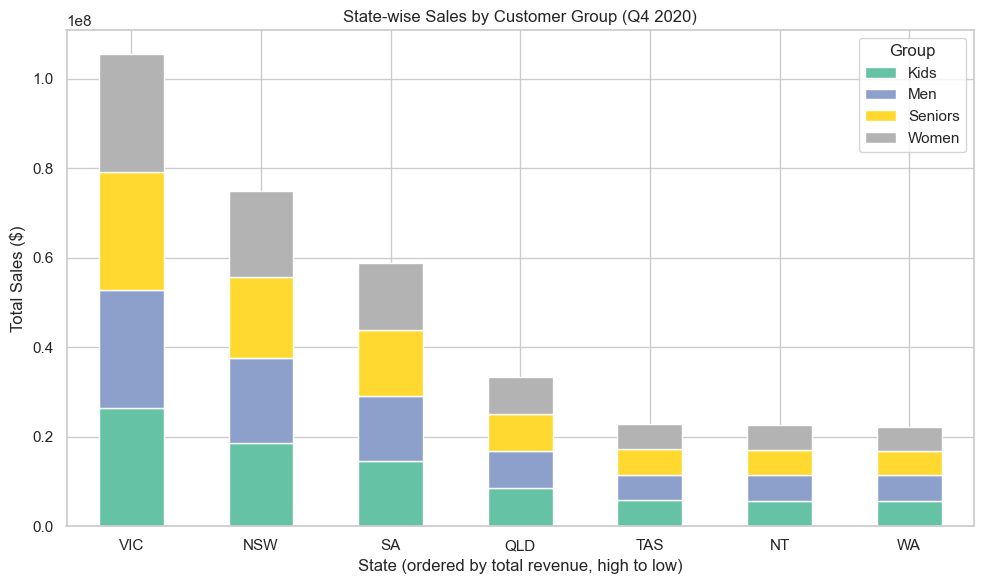

In [19]:
pivot_state_group = df.pivot_table(index='State', columns='Group', values='Sales',
                                    aggfunc='sum', observed=True)
pivot_state_group = pivot_state_group.loc[state_summary.index]  # order by total revenue

fig, ax = plt.subplots(figsize=(10,6))
pivot_state_group.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
ax.set_title('State-wise Sales by Customer Group (Q4 2020)')
ax.set_ylabel('Total Sales ($)')
ax.set_xlabel('State (ordered by total revenue, high to low)')
ax.legend(title='Group')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('viz_state_by_group.png')
plt.show()

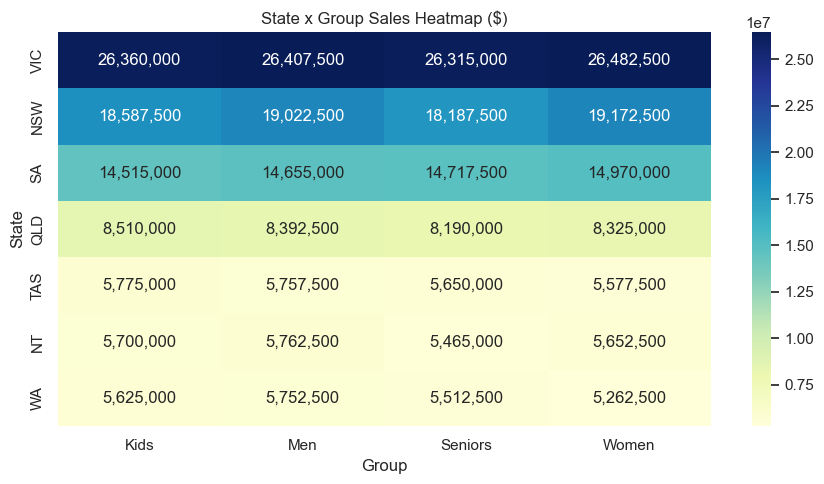

In [22]:
fig, ax = plt.subplots(figsize=(9,5))
sns.heatmap(pivot_state_group, annot=True, fmt=',.0f', cmap='YlGnBu', ax=ax)
ax.set_title('State x Group Sales Heatmap ($)')
plt.tight_layout()
plt.savefig('viz_state_group_heatmap.png')
plt.show()

#### Group-wise sales analysis across states

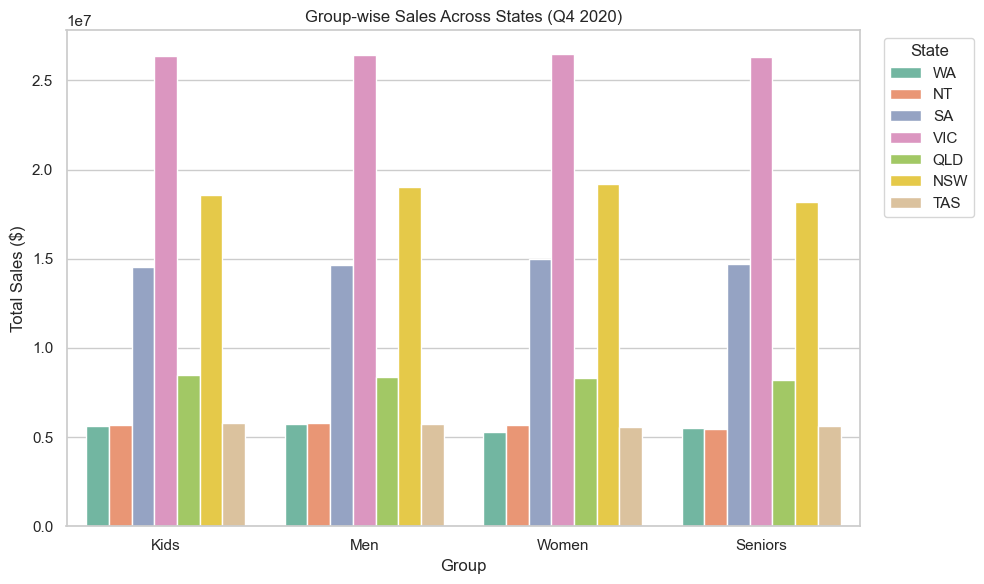

In [21]:
fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(data=df, x='Group', y='Sales', hue='State', estimator=sum, errorbar=None, ax=ax)
ax.set_title('Group-wise Sales Across States (Q4 2020)')
ax.set_ylabel('Total Sales ($)')
ax.legend(title='State', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.savefig('viz_group_by_state.png')
plt.show()

#### Time-of-day analysis

In [23]:
time_summary = df.groupby('Time', observed=True)[['Sales','Unit']].sum()
time_summary

,Sales,Unit
Time,,
Morning,114207500,45683
Afternoon,114007500,45603
Evening,112087500,44835


/var/folders/rm/h6p7xn2s0xd3jhy1lt9lmlr00000gn/T/ipykernel_67522/3556379302.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Time', y='Sales', estimator=sum, errorbar=None,


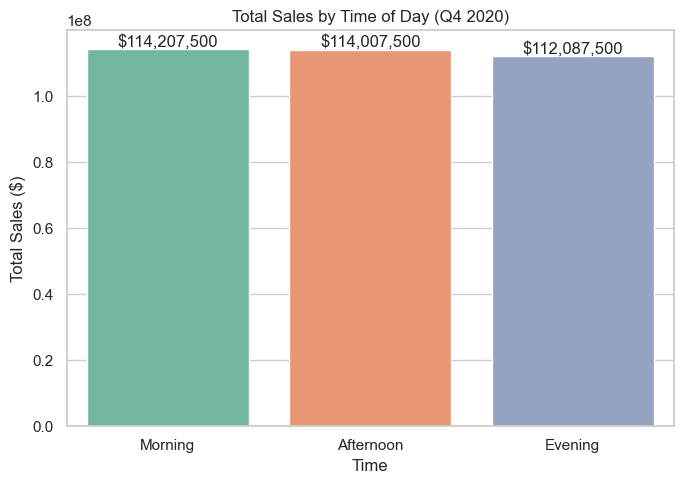

Highest-selling time of day: Morning
Lowest-selling time of day : Evening


In [24]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=df, x='Time', y='Sales', estimator=sum, errorbar=None,
            order=['Morning','Afternoon','Evening'], ax=ax, palette='Set2')
ax.set_title('Total Sales by Time of Day (Q4 2020)')
ax.set_ylabel('Total Sales ($)')

for i, v in enumerate(time_summary.loc[['Morning', 'Afternoon', 'Evening'], 'Sales']):
    ax.text(i, v, f'${v:,.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('viz_time_of_day.png')
plt.show()

best_time = time_summary['Sales'].idxmax()
worst_time = time_summary['Sales'].idxmin()

print(f"Highest-selling time of day: {best_time}")
print(f"Lowest-selling time of day : {worst_time}")

#### Dashboard: Daily, Weekly, Monthly, Quarterly sales trends

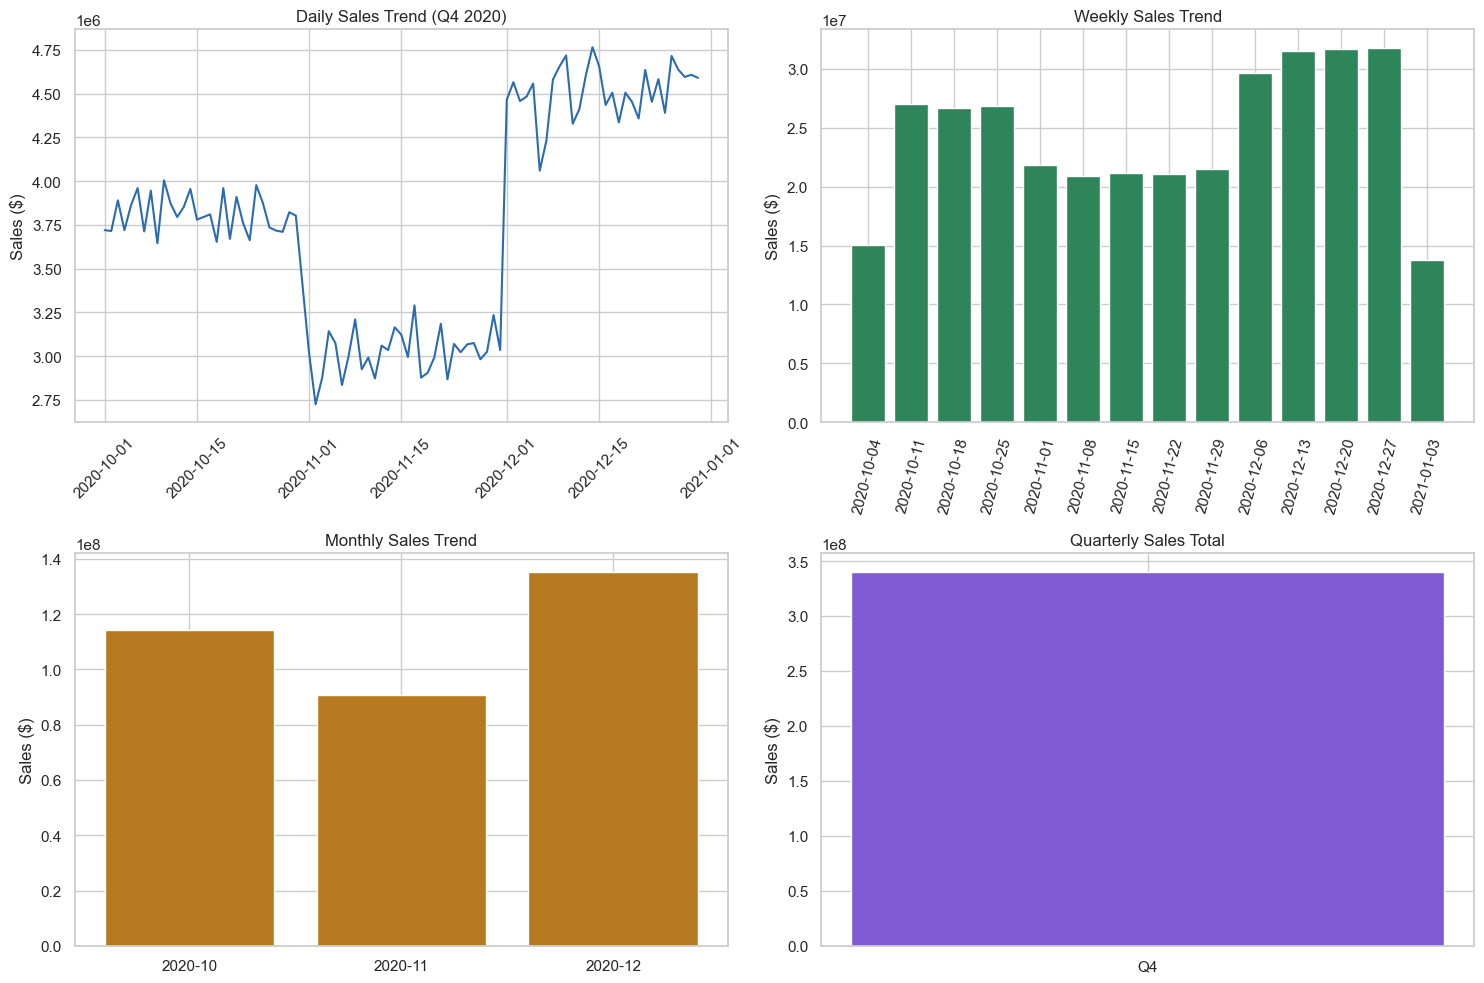

In [25]:
daily = df.groupby('Date')['Sales'].sum()

fig, axes = plt.subplots(2, 2, figsize=(15,10))

# Daily
axes[0,0].plot(daily.index, daily.values, color='#2b6cb0')
axes[0,0].set_title('Daily Sales Trend (Q4 2020)')
axes[0,0].set_ylabel('Sales ($)')
axes[0,0].tick_params(axis='x', rotation=45)

# Weekly
wk = df.groupby(pd.Grouper(key='Date', freq='W'))['Sales'].sum()
axes[0,1].bar(wk.index.astype(str), wk.values, color='#2f855a')
axes[0,1].set_title('Weekly Sales Trend')
axes[0,1].set_ylabel('Sales ($)')
axes[0,1].tick_params(axis='x', rotation=75)

# Monthly
mo = df.groupby(pd.Grouper(key='Date', freq='ME'))['Sales'].sum()
axes[1,0].bar(mo.index.to_period('M').astype(str), mo.values, color='#b7791f')
axes[1,0].set_title('Monthly Sales Trend')
axes[1,0].set_ylabel('Sales ($)')

# Quarterly (single Q4 bar, shown for completeness / template for full-year use)
q = df.groupby('Quarter')['Sales'].sum()
axes[1,1].bar(['Q' + str(i) for i in q.index], q.values, color='#805ad5')
axes[1,1].set_title('Quarterly Sales Total')
axes[1,1].set_ylabel('Sales ($)')

plt.tight_layout()
plt.savefig('viz_dashboard_trends.png')
plt.show()

#### Box plot: descriptive statistics of Sales and Unit

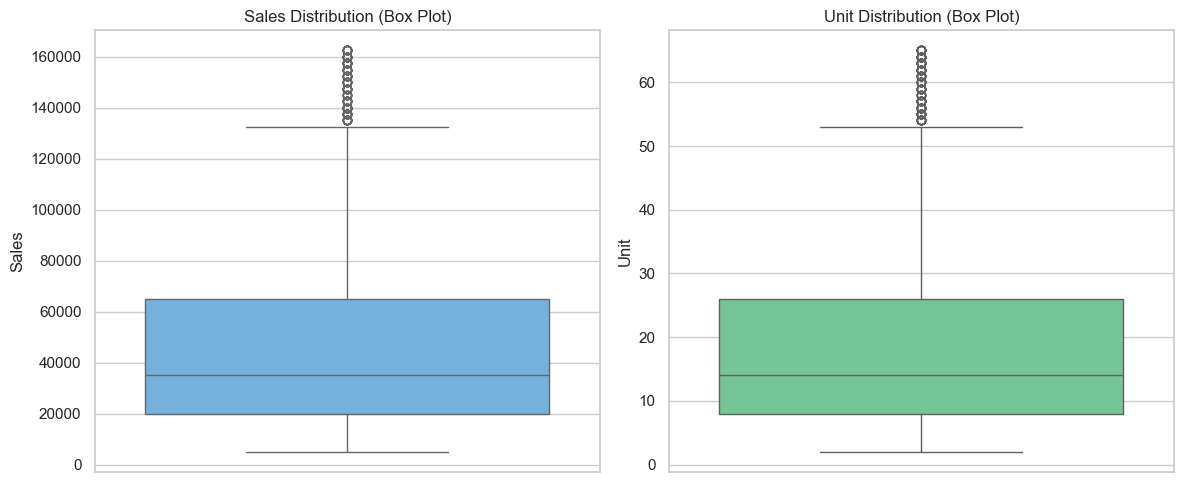

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(data=df, y='Sales', ax=axes[0], color='#63b3ed')
axes[0].set_title('Sales Distribution (Box Plot)')
sns.boxplot(data=df, y='Unit', ax=axes[1], color='#68d391')
axes[1].set_title('Unit Distribution (Box Plot)')
plt.tight_layout()
plt.savefig('viz_boxplots.png')
plt.show()

/var/folders/rm/h6p7xn2s0xd3jhy1lt9lmlr00000gn/T/ipykernel_67522/876964642.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='State', y='Sales', order=state_summary.index, ax=ax, palette='Set2')


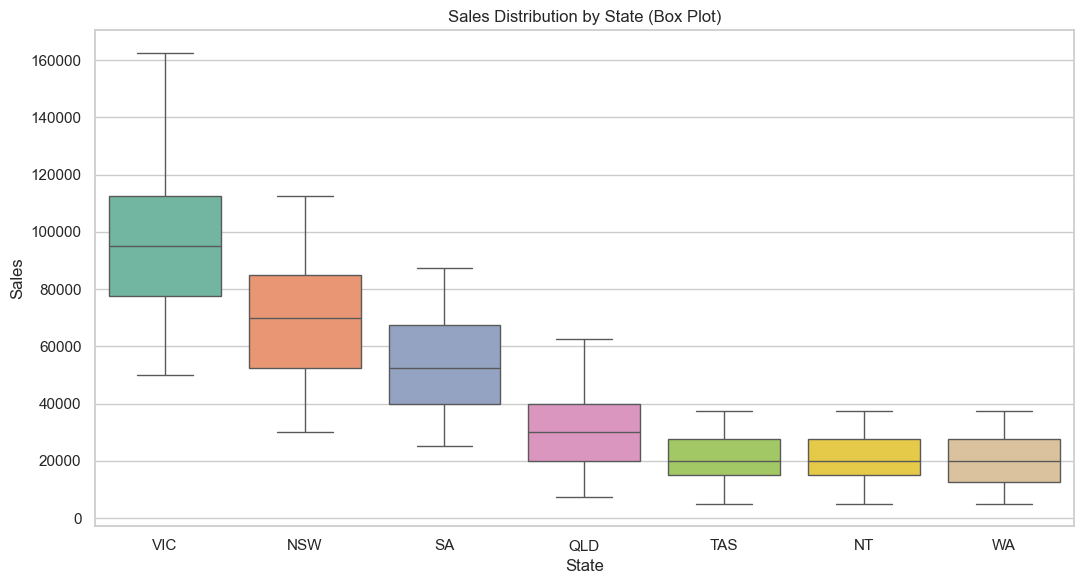

In [27]:
fig, ax = plt.subplots(figsize=(11,6))
sns.boxplot(data=df, x='State', y='Sales', order=state_summary.index, ax=ax, palette='Set2')
ax.set_title('Sales Distribution by State (Box Plot)')
plt.tight_layout()
plt.savefig('viz_boxplot_by_state.png')
plt.show()

#### Seaborn distribution plots

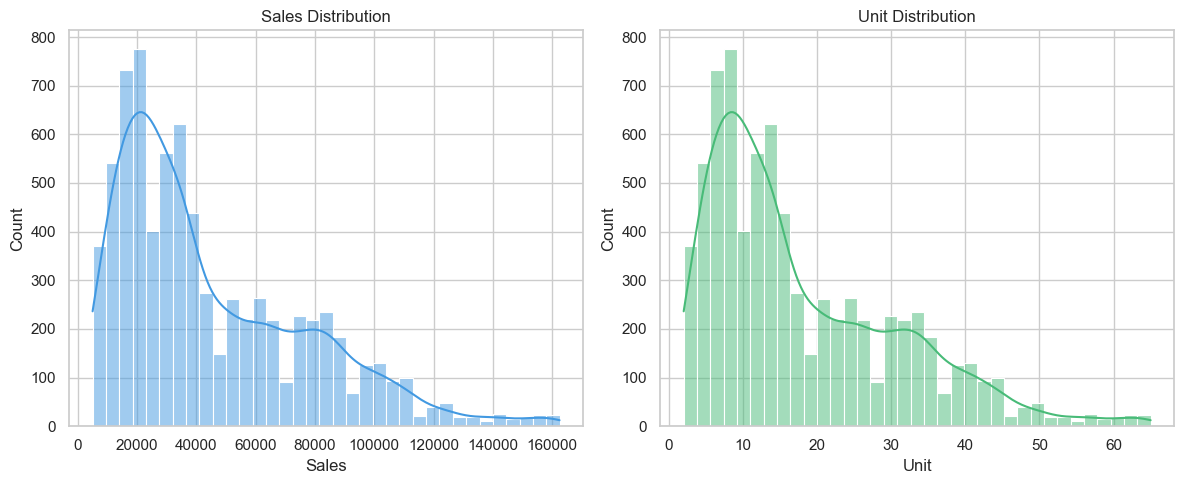

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(df['Sales'], kde=True, ax=axes[0], color='#4299e1')
axes[0].set_title('Sales Distribution')
sns.histplot(df['Unit'], kde=True, ax=axes[1], color='#48bb78')
axes[1].set_title('Unit Distribution')
plt.tight_layout()
plt.savefig('viz_distplots.png')
plt.show()

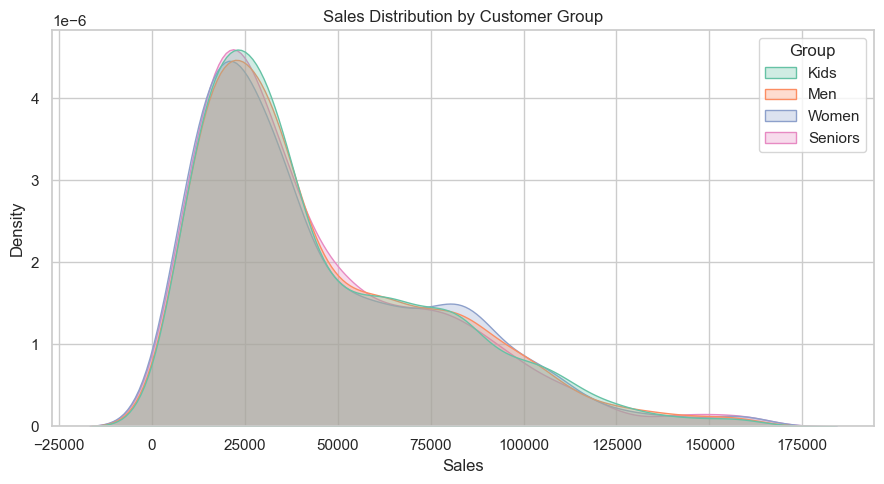

In [29]:
fig, ax = plt.subplots(figsize=(9,5))
sns.kdeplot(data=df, x='Sales', hue='Group', fill=True, alpha=0.3, ax=ax)
ax.set_title('Sales Distribution by Customer Group')
plt.tight_layout()
plt.savefig('viz_distplot_by_group.png')
plt.show()

# 4. Recommendation report for the Head of Sales & Marketing

Based on the analysis, the customer group and state with the highest sales should continue to receive investment and marketing support, as they contribute the most revenue. Strategies that have been successful in these areas can also be applied to similar markets.

For the lowest-performing state and customer group, the following actions are recommended:
- Introduce targeted promotional campaigns in underperforming states to increase customer engagement and sales.
- Develop customer-specific marketing campaigns, such as loyalty programs or bundled offers, for lower-performing customer groups instead of offering general discounts.
- Schedule promotional offers and personalized recommendations during the highest-selling times of the day to maximize customer response.
- Evaluate the effectiveness of promotional campaigns before expanding into new locations by monitoring weekly and monthly sales performance.

To improve future analyses and decision-making:
- Continue recording transaction dates and times, as these provide valuable insights into sales trends and customer behaviour.
- Maintain consistent formatting of categorical data, such as state and customer group names, to ensure accurate analysis.
- Update the analysis regularly using new quarterly data to monitor performance and measure the effectiveness of implemented strategies.